Based on https://github.com/huggingface/smollm/blob/main/vision/finetuning/Smol_VLM_FT.ipynb


train_ds: Dataset({
    features: ['multiple_choice_answer', 'question', 'image'],
    num_rows: 10717
})
test_ds: Dataset({
    features: ['multiple_choice_answer', 'question', 'image'],
    num_rows: 10718
})
train_ds sample : {'multiple_choice_answer': 'bathroom', 'question': 'Where is this person?', 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x375 at 0x16FE0CB50>}
The image is: <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x375 at 0x16FE0C1C0>


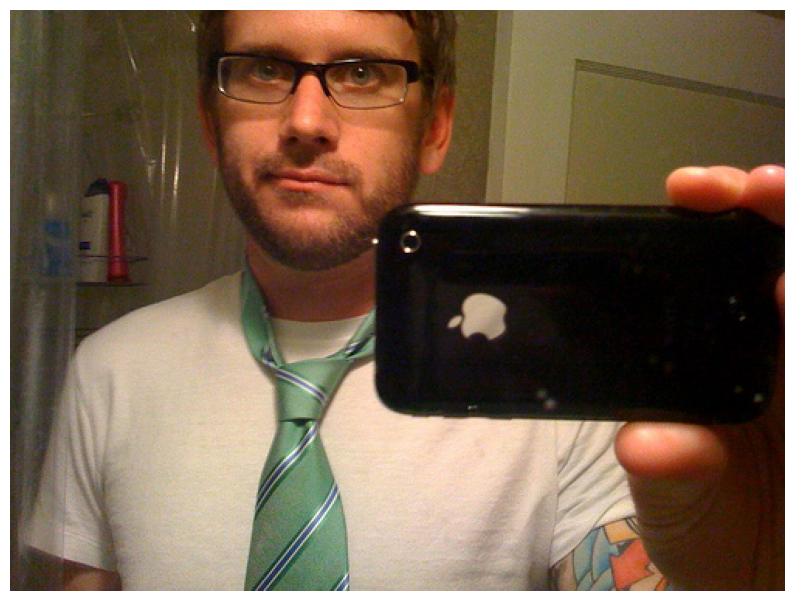

The question is: Where is this person?


In [2]:
from transformers import AutoProcessor, AutoModelForVision2Seq
import torch
from datasets import load_dataset
import matplotlib.pyplot as plt


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoProcessor.from_pretrained("HuggingFaceTB/SmolVLM-Instruct")
model = AutoModelForVision2Seq.from_pretrained(
    "HuggingFaceTB/SmolVLM-Instruct",                                                
    torch_dtype=torch.bfloat16,
    _attn_implementation="flash_attention_2" if DEVICE == "cuda" else "eager").to(DEVICE)

# get approriate data for SmolVLM
# https://huggingface.co/datasets/HuggingFaceTB/SmolVLM-Instruct-Data


# load data
ds = load_dataset('merve/vqav2-small', trust_remote_code=True)
split_ds = ds["validation"].train_test_split(test_size=0.5)
train_ds = split_ds["train"]
test_ds = split_ds["test"]

print(f"train_ds: {train_ds}")
print(f"test_ds: {test_ds}")

print(f"train_ds sample : {train_ds[0]}")
print(f"The image is: {train_ds[0]['image']}")

plt.figure(figsize=(10, 10))
plt.imshow(train_ds[0]['image'])
plt.axis('off')
plt.show()

print(f"The question is: {train_ds[0]['question']}")





In [4]:
from PIL import Image
from transformers.image_utils import load_image


# Load images
image1 = load_image("https://huggingface.co/spaces/HuggingFaceTB/SmolVLM/resolve/main/example_images/rococo.jpg")
image2 = load_image("https://huggingface.co/spaces/HuggingFaceTB/SmolVLM/resolve/main/example_images/rococo_1.jpg")

# Create input messages
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "image"},
            {"type": "text", "text": "Can you describe the two images?"}
        ]
    },
]

# Prepare inputs
prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
inputs = processor(text=prompt, images=[image1, image2], return_tensors="pt")
inputs = inputs.to(DEVICE)

# Generate outputs
generated_ids = model.generate(**inputs, max_new_tokens=500)
generated_texts = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True,
)

print(generated_texts[0])



KeyboardInterrupt: 